# 02. Modelo Predictivo - El consumidor disputara la queja?


## Librerias

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, mean_absolute_error
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelBinarizer
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_recall_curve










## Carga del dataset limpio

In [2]:
dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')
dt_quejas.head(20)


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Jon\AppData\Local\Temp\ipykernel_15428\1742754170.py:1: SyntaxWarning: invalid escape sequence '\d'
  dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')


,Complaint ID,Product,Sub-product,Issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,Company_grouped_filtered,Difference in days
0,1291006,Debt collection,Credit card,Communication tactics,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending,Low Count Companies,0
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,Low Count Companies,0
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",MA,02127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,RBS Citizens,0
3,1291615,Credit card,Unknown,Other,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending,Navy FCU,0
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,OH,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending,Transworld Systems Inc.,0
5,1291176,Debt collection,Payday loan,Communication tactics,OH,43068,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,Pending,ACE Cash Express Inc.,0
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,OH,44241,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes,"CashCall, Inc.",0
7,1288788,Debt collection,Payday loan,Communication tactics,CA,95124,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No,ACE Cash Express Inc.,0
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,NJ,07067,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No,Low Count Companies,0
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,TX,77433,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes,Low Count Companies,0


## Modelos a realizar

#### Definimos X e Y

In [3]:
y = dt_quejas['Consumer disputed?']

caracteristicas = [
    'Product',
    'Issue',
    'Company response',
    'Timely response?',
    'Company_grouped_filtered',
    'State',
    'Difference in days'
    
]

caracteristicas_con_subproduct = caracteristicas + ['Sub-product']
caracteristicas_sin_subproduct = caracteristicas.copy()

X_con_subproduct = dt_quejas[caracteristicas_con_subproduct]
X_sin_subproduct = dt_quejas[caracteristicas_sin_subproduct]

#### Modelo con Random Forest

In [4]:
def entrenar_modelo(X, y, labels):
    categoricas = X.select_dtypes(include='object').columns.tolist()
    numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas)
        ],
        remainder='passthrough'
    )

    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)

    print(" Classification Report:\n", classification_report(y_test, y_pred))
    print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    print("\n Métricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    if y_test_bin.shape[1] == 1:
        print("ROC AUC: sólo hay una clase activa, no se puede calcular.")
    else:
        auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        print(f"ROC AUC (OvR): {auc:.4f}")

    return clf


In [5]:
modelo_con_sub = entrenar_modelo(X_con_subproduct, y, labels=['No', 'Pending', 'Yes'])
modelo_sin_subproduct = entrenar_modelo(X_sin_subproduct, y,labels=['No', 'Pending', 'Yes'])


 Classification Report:
               precision    recall  f1-score   support

          No       0.82      0.89      0.85      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.24      0.15      0.19       942

    accuracy                           0.78      5632
   macro avg       0.69      0.68      0.68      5632
weighted avg       0.74      0.78      0.76      5632

 Confusion Matrix:
 [[3625    0  457]
 [   0  608    0]
 [ 797    0  145]]

 Métricas adicionales:
Accuracy: 0.7773
Precision (macro): 0.6869
Recall (macro): 0.6807
F1-score (macro): 0.6801
F1-score (weighted): 0.7573
ROC AUC (OvR): 0.7880
 Classification Report:
               precision    recall  f1-score   support

          No       0.82      0.86      0.84      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.24      0.19      0.21       942

    accuracy                           0.76      5632
   macro avg       0.69      0.68      0.68      5632
wei

Se evaluaron dos modelos de Random Forest para la clasificación del dataset para tres clases: "No", "Pending" y "Yes" en relacion a si el consumidor disputara la queja. En términos generales, ambos modelos presentan un rendimiento aceptable para la clase mayoritaria ("No") y la clase intermedia ("Pending"), pero muestran dificultades importantes para predecir la clase minoritaria ("Yes"). Esto se refleja en las métricas de precisión, recall y F1-score, donde la clase "Yes" obtiene valores significativamente bajos en ambos casos.

Al analizar el primer modelo, se observa una precisión de 0.82 y un recall de 0.89 para la clase "No", mientras que para "Pending" se alcanzan valores perfectos de 1.00 en ambas métricas. La clase "Yes", en cambio, presenta un recall de solo 0.15 y un F1-score de 0.19, indicando que muchas observaciones de esta clase son clasificadas incorrectamente. La matriz de confusión confirma esto: 797 instancias de "Yes" fueron clasificadas como "No". El modelo obtiene una exactitud global de 77.7% y un ROC AUC de 0.7880, lo que indica un desempeño moderado general.

En el segundo modelo, donde se eliminó la variable adicional, se aprecia una ligera disminución en la exactitud global a 76.1% y un ROC AUC de 0.7847. Las métricas por clase muestran que el recall de la clase "No" baja a 0.86 y el F1-score a 0.84, mientras que la clase "Yes" mejora marginalmente su recall a 0.19 y el F1-score a 0.21. La matriz de confusión evidencia un aumento en los falsos negativos para la clase "No" (586 instancias clasificadas incorrectamente como "Yes"), pero una recuperación ligera para la clase "Yes" con más casos correctamente identificados (182 frente a 145).

##### Oversampling de la clase mayoritaria

In [6]:
def entrenar_modelo_con_smote(X, y, labels):

    categoricas = X.select_dtypes(include='object').columns.tolist()
    numericas= X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas)
        ],
        remainder='passthrough'
    )

    X_train_enc = preprocessor.fit_transform(X_train)
    X_test_enc = preprocessor.transform(X_test)

    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train_enc, y_train)

    clf = RandomForestClassifier(class_weight='balanced', random_state=42)
    clf.fit(X_resampled, y_resampled)

    y_pred = clf.predict(X_test_enc)
    y_proba = clf.predict_proba(X_test_enc)

    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    print("\n Métricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    if y_test_bin.shape[1] == 1:
        print("ROC AUC: sólo hay una clase activa, no se puede calcular.")
    else:
        auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        print(f"ROC AUC (OvR): {auc:.4f}")

    return clf

In [ ]:
modelo_con_sub = entrenar_modelo_con_smote(X_con_subproduct, y, labels=['No', 'Pending', 'Yes']))
modelo_sin_subproduct = entrenar_modelo_con_smote(X_sin_subproduct, y,labels=['No', 'Pending', 'Yes'])

Classification Report:
               precision    recall  f1-score   support

          No       0.82      0.91      0.86      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.25      0.13      0.17       942

    accuracy                           0.79      5632
   macro avg       0.69      0.68      0.68      5632
weighted avg       0.74      0.79      0.76      5632

Confusion Matrix:
 [[3723    0  359]
 [   0  608    0]
 [ 821    0  121]]

 Métricas adicionales:
Accuracy: 0.7905
Precision (macro): 0.6905
Recall (macro): 0.6802
F1-score (macro): 0.6778
F1-score (weighted): 0.7621
ROC AUC (OvR): 0.7886
Classification Report:
               precision    recall  f1-score   support

          No       0.82      0.89      0.86      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.24      0.15      0.18       942

    accuracy                           0.78      5632
   macro avg       0.69      0.68      0.68      5632
weight

Se han entrenado dos modelos de clasificación para predecir si un consumidor disputará una queja, esta vez incluyendo un enfoque de balanceo de clases mediante SMOTE (Synthetic Minority Oversampling Technique). El objetivo era mejorar la capacidad del modelo para detectar correctamente la clase minoritaria: "Yes". 

Este modelo muestra una accuracy del 0.79, lo que ya es una ligera mejora frente al baseline sin SMOTE. La clase "No" mantiene un rendimiento sólido (f1-score = 0.86) y la clase "Pending" sigue siendo perfecta en todas las métricas. Sin embargo, la clase "Yes" sigue mostrando debilidades: solo alcanza un f1-score de 0.17, con un recall bastante bajo (0.13).La matriz de confusión muestra que de 942 casos "Yes", el modelo solo acierta 121 y clasifica erróneamente 821 como "No". Aunque el accuracy global mejora, esto revela que SMOTE no resolvió del todo la detección de la clase minoritaria, ya que la confusión sigue siendo elevada.El macro f1-score (0.678) y el ROC AUC (0.789) se mantienen similares a los otros modelos analizados. Esto sugiere que, aunque SMOTE aporta algo de equilibrio en el dataset, el modelo todavía no está aprovechando bien esa información sintética. En conclusión, esta configuración mejora un poco la estabilidad global, pero no representa un salto significativo en el rendimiento de la clase "Yes".

El segundo experimento muestra métricas casi idénticas a la primera corrida, con una accuracy de 0.78. La clase "No" baja un poco en recall (0.89 vs 0.91), pero mantiene un f1-score alto (0.86). La clase "Pending" sigue sin problemas (1.00).La clase "Yes" mejora levemente su recall (0.15 vs 0.13) y f1-score (0.18 vs 0.17), pero las diferencias son mínimas. En la matriz de confusión se aprecia que detecta 138 casos correctos de "Yes", mejor que los 121 del primer modelo, pero aún con 804 clasificados erróneamente como "No". Las métricas macro y el AUC (0.785) se mantienen en la misma línea, mostrando que no hay una ganancia real en discriminación global. La variación entre las dos corridas refleja solo fluctuaciones normales del modelo, sin un cambio sustancial.


##### Hiperparametrizacion con y sin SMOTE

In [36]:
def entrenar_modelo_gs(X, y, labels):
    categoricas = X.select_dtypes(include='object').columns.tolist()
    numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas)
        ],
        remainder='passthrough'
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    param_grid = {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [12,18],
        'classifier__min_samples_leaf': [2,4],
        'classifier__class_weight': ['balanced']
    }

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)

    print(" Classification Report:\n", classification_report(y_test, y_pred))
    print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    print("\n Métricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    if y_test_bin.shape[1] == 1:
        print("ROC AUC: solo hay una clase activa, no se puede calcular.")
    else:
        auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        print(f"ROC AUC (OvR): {auc:.4f}")

    print(f"\n Mejores parámetros encontrados: {grid_search.best_params_}")

    return best_model


In [37]:
modelo_gs = entrenar_modelo_gs(X_con_subproduct, y, labels=['No', 'Pending', 'Yes'])

Fitting 3 folds for each of 24 candidates, totalling 72 fits
 Classification Report:
               precision    recall  f1-score   support

          No       0.84      0.73      0.78      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.25      0.38      0.30       942

    accuracy                           0.70      5632
   macro avg       0.69      0.71      0.69      5632
weighted avg       0.76      0.70      0.72      5632

 Confusion Matrix:
 [[2987    1 1094]
 [   0  608    0]
 [ 580    0  362]]

 Métricas adicionales:
Accuracy: 0.7026
Precision (macro): 0.6948
Recall (macro): 0.7053
F1-score (macro): 0.6940
F1-score (weighted): 0.7244
ROC AUC (OvR): 0.8014

 Mejores parámetros encontrados: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 12, 'classifier__n_estimators': 100}


El modelo de Random Forest con hiperparametrizacion presenta un desempeño diferente al baseline. La accuracy baja a 0.70, lo que a primera vista parece un empeoramiento frente a los anteriores modelos (~0.76–0.79). Sin embargo, el ajuste de hiperparámetros con class_weight=balanced cambia el comportamiento del modelo: ahora la clase "Yes" mejora en recall (0.38 frente al ~0.13–0.19 anterior) y logra un f1-score de 0.30, que es un progreso notable en comparación con los otros intentos.

En la matriz de confusión se ve claramente este efecto: el modelo acierta 362 casos "Yes", cuando antes solo alcanzaba entre 121 y 182. No obstante, este avance en la clase minoritaria se paga con un mayor número de errores en la clase mayoritaria "No" (1094 clasificados mal como "Yes"), lo que reduce la precisión global. En otras palabras, el modelo se vuelve más sensible pero menos preciso. Las métricas macro muestran valores equilibrados (f1 = 0.69, recall = 0.71), bastante mejores que los ~0.68 de los otros modelos. Además, el AUC sube a 0.80, indicando una mejor capacidad de discriminación entre clases. Esto significa que, aunque la accuracy baje, el modelo está más balanceado entre clases y se acerca más a lo que se busca en un escenario desbalanceado.

En conclusión, el Grid Search con class_weight=balanced logra un trade-off interesante: sacrifica exactitud global para dar más relevancia a la clase minoritaria, mejorando su recall y f1-score. Si el objetivo principal es detectar correctamente la clase "Yes", este modelo es claramente superior a los anteriores.

In [40]:
def entrenar_modelo_gs(X, y, labels, use_smote=True):

    categoricas = X.select_dtypes(include='object').columns.tolist()
    numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas)
        ],
        remainder='passthrough'
    )

    if use_smote:
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', RandomForestClassifier(random_state=42))
        ])
        param_grid = {
            'classifier__n_estimators': [75,125],
            'classifier__max_depth': [None, 20,40],
            'classifier__min_samples_split': [2,6],
            'classifier__min_samples_leaf': [4,6],
            'classifier__class_weight': ['balanced'] }
    else:
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(random_state=42))
        ])
        param_grid = {
            'classifier__n_estimators': [50,100],
            'classifier__max_depth': [None, 10,20],
            'classifier__min_samples_split': [12,18],
            'classifier__min_samples_leaf': [2,4],
            'classifier__class_weight': ['balanced']
        }

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)

    print(" Classification Report:\n", classification_report(y_test, y_pred))
    print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    print("\n Métricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    if y_test_bin.shape[1] == 1:
        print("ROC AUC: solo hay una clase activa, no se puede calcular.")
    else:
        auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        print(f"ROC AUC (OvR): {auc:.4f}")

    print(f"\n Mejores parámetros encontrados: {grid_search.best_params_}")
    print(f" SMOTE activado: {use_smote}")

    return best_model

In [41]:
labels = ['No', 'Pending', 'Yes']

modelo_smote = entrenar_modelo_gs(X_con_subproduct, y, labels, use_smote=True)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
 Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.76      0.80      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.25      0.35      0.29       942

    accuracy                           0.72      5632
   macro avg       0.70      0.70      0.70      5632
weighted avg       0.75      0.72      0.73      5632

 Confusion Matrix:
 [[3114    0  968]
 [   0  608    0]
 [ 617    0  325]]

 Métricas adicionales:
Accuracy: 0.7186
Precision (macro): 0.6953
Recall (macro): 0.7026
F1-score (macro): 0.6960
F1-score (weighted): 0.7343
ROC AUC (OvR): 0.7993

 Mejores parámetros encontrados: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 125}
 SMOTE activado: True


Tras aplicarle SMOTE modelo alcanza una accuracy de 0.72, algo mayor que la obtenida con Grid Search sin SMOTE (0.70). La clase "Pending" sigue siendo perfecta (f1 = 1.00), mientras que la clase "No" se mantiene sólida (f1 = 0.80). Lo más relevante está en la clase "Yes", que obtiene un f1-score de 0.29, con un recall de 0.35, cifras muy similares al modelo con Grid Search sin SMOTE (0.30 y 0.38 respectivamente).

En la matriz de confusión se aprecia que el modelo detecta 325 casos "Yes" correctamente, frente a los 362 del Grid Search sin SMOTE. Es decir, pierde un poco de recall (35% vs 38%), pero mejora el rendimiento en "No" (menos falsos positivos, 968 en vez de 1094). Este balance hace que la precisión global y el weighted f1-score suban ligeramente (0.734 vs 0.724).

Las métricas macro son bastante equilibradas (f1 = 0.696, recall = 0.703), y el ROC AUC se mantiene alto (0.799), lo que confirma que el modelo tiene buena capacidad de discriminación general. El ajuste de hiperparámetros (max_depth=20, min_samples_leaf=6, n_estimators=125) parece haber encontrado un punto intermedio que evita el sobreajuste y mantiene la estabilidad.

En conclusión, el modelo con Grid Search + SMOTE logra un mejor trade-off: mantiene la sensibilidad de la clase minoritaria en niveles aceptables (aunque un poco menores que sin SMOTE) y a la vez reduce los errores en la clase mayoritaria, lo que mejora las métricas globales. Si el objetivo es un modelo más balanceado y con buen desempeño general, este es el candidato más sólido hasta ahora.

##### Modelo XGBoost

In [12]:
def entrenar_xgb_basico(X, y, labels, usar_pesos_clase=True):
    
    label_to_num = {label: i for i, label in enumerate(labels)}
    num_to_label = {i: label for label, i in label_to_num.items()}
    y_num = y.map(label_to_num)

    
    cat_features = X.select_dtypes(include='object').columns.tolist()

  
    X_train, X_test, y_train_num, y_test_num = train_test_split(
        X, y_num, stratify=y_num, test_size=0.2, random_state=42
    )


    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)],
        remainder='passthrough'
    )


    xgb = XGBClassifier(
        objective='multi:softprob',
        num_class=len(labels),
        eval_metric='mlogloss',
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb)
    ])

    fit_kwargs = {}
    if usar_pesos_clase:
        classes_num = np.arange(len(labels))
        pesos = compute_class_weight(
            class_weight='balanced',
            classes=classes_num,
            y=y_train_num.values
        )
        mapa_pesos = {cls: w for cls, w in zip(classes_num, pesos)}
        sample_weight = pd.Series(y_train_num).map(mapa_pesos).values
        fit_kwargs['classifier__sample_weight'] = sample_weight


    pipe.fit(X_train, y_train_num, **fit_kwargs)


    y_pred_num  = pipe.predict(X_test)
    y_proba     = pipe.predict_proba(X_test)


    y_test = pd.Series(y_test_num).map(num_to_label)
    y_pred = pd.Series(y_pred_num).map(num_to_label)

    print("Classification Report:\n",
          classification_report(y_test_num, y_pred_num,
                                labels=list(range(len(labels))),
                                target_names=labels))
    print("Confusion Matrix:\n",
          confusion_matrix(y_test_num, y_pred_num, labels=list(range(len(labels)))))

    print("\n Métricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test_num, y_pred_num):.4f}")
    print(f"Precision (macro): {precision_score(y_test_num, y_pred_num, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test_num, y_pred_num, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test_num, y_pred_num, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test_num, y_pred_num, average='weighted'):.4f}")


    lb = LabelBinarizer().fit(y_test_num)
    y_test_bin = lb.transform(y_test_num)
    if y_test_bin.shape[1] > 1:
        auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        print(f"ROC AUC (OvR): {auc:.4f}")

    return pipe

In [13]:
labels = ['No', 'Pending', 'Yes']

features_with_subproduct = [
    'Product', 'Sub-product', 'Issue', 'State', 'ZIP code',
    'Company_grouped_filtered', 'Company response', 'Timely response?',
    'Difference in days'
]
X_with_subproduct = dt_quejas[features_with_subproduct]
y = dt_quejas['Consumer disputed?']

modelo_xgb_con_sub = entrenar_xgb_basico(
    X=X_with_subproduct,
    y=y,
    labels=labels,
    usar_pesos_clase=False
)


Classification Report:
               precision    recall  f1-score   support

          No       0.82      0.99      0.90      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.60      0.04      0.08       942

    accuracy                           0.84      5632
   macro avg       0.81      0.68      0.66      5632
weighted avg       0.80      0.84      0.77      5632

Confusion Matrix:
 [[4056    0   26]
 [   0  608    0]
 [ 903    0   39]]

 Métricas adicionales:
Accuracy: 0.8350
Precision (macro): 0.8060
Recall (macro): 0.6783
F1-score (macro): 0.6582
F1-score (weighted): 0.7712
ROC AUC (OvR): 0.8103


Con el XBooost obtenemos una accuracy bastante alta (0.84), superando claramente a los Random Forest probados anteriormente. La clase "No" alcanza un rendimiento excelente (f1 = 0.90) y la clase "Pending" se clasifica de manera perfecta (f1 = 1.00). Estos resultados explican el elevado accuracy general, ya que el modelo acierta casi todos los casos de las clases mayoritarias.

El problema aparece con la clase "Yes". Aunque la precisión es buena (0.60), el recall es extremadamente bajo (0.04), lo que da como resultado un f1-score de solo 0.08. En la matriz de confusión se observa claramente: de 942 casos positivos, solo 39 se predicen bien, mientras que 903 se confunden como "No". Esto indica que el modelo es muy conservador con la clase minoritaria, casi siempre inclinándose a clasificar como "No".

Las métricas macro lo reflejan bien: precisión media alta (0.81) pero recall bajo (0.68) y f1-score bajo (0.66). A pesar de eso, el ROC AUC es el más alto hasta ahora (0.81), lo que sugiere que el modelo sí tiene capacidad para discriminar entre clases, pero probablemente con un umbral de decisión demasiado estricto que perjudica la detección de "Yes".

En resumen, XGBoost baseline es excelente para las clases mayoritarias y consigue la mayor accuracy global, pero prácticamente falla en la clase "Yes". Esto lo convierte en un modelo con gran potencial, pero que necesita ajustes: cambio de umbral, balanceo de clases (scale_pos_weight) o técnicas de re-muestreo para mejorar su sensibilidad en la clase minoritaria.

In [14]:
def entrenar_xgb_pesos(X, y, labels):
    cat_features = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)],
        remainder='passthrough'
    )

    counts = Counter(y_train)
    total = sum(counts.values())
    pesos = {cls: total / count for cls, count in counts.items()}
    sample_weight = y_train.map(pesos).values

    xgb = XGBClassifier(
        objective='multi:softprob',
        num_class=len(labels),
        eval_metric='mlogloss',
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb)
    ])

    pipe.fit(X_train, y_train, classifier__sample_weight=sample_weight)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)

    print(" Classification Report:\n", classification_report(y_test, y_pred))
    print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")

    lb = LabelBinarizer().fit(y_test)
    y_test_bin = lb.transform(y_test)
    if y_test_bin.shape[1] > 1:
        auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        print(f"ROC AUC (OvR): {auc:.4f}")

    return pipe


In [15]:
labels = ['No', 'Pending', 'Yes']

features_with_subproduct = [
    'Product', 'Sub-product', 'Issue', 'State', 'ZIP code',
    'Company_grouped_filtered', 'Company response', 'Timely response?',
    'Difference in days'
]

X = dt_quejas[features_with_subproduct]
y = dt_quejas['Consumer disputed?']

label_to_num = {label: i for i, label in enumerate(labels)} 
y_num = y.map(label_to_num)

modelo_xgb_pesos = entrenar_xgb_pesos(X=X, y=y_num, labels=labels)

 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.61      0.71      4082
           1       1.00      1.00      1.00       608
           2       0.24      0.54      0.34       942

    accuracy                           0.64      5632
   macro avg       0.70      0.72      0.68      5632
weighted avg       0.77      0.64      0.68      5632

 Confusion Matrix:
 [[2487    0 1595]
 [   0  608    0]
 [ 431    0  511]]

Accuracy: 0.6403
F1 Macro: 0.6820
ROC AUC (OvR): 0.8099


Tras ajustar los pesos,  la accuracy baja bastante (0.64) en comparación con el baseline (0.84). Esto se debe a que el modelo, al dar más importancia a la clase minoritaria, sacrifica rendimiento en la clase mayoritaria. De hecho, la clase "No" cae en recall (0.61 frente a 0.99 antes), lo que reduce su f1-score a 0.71.

Por otro lado, la clase "Yes" mejora de forma muy notable: pasa de un recall de 0.04 a 0.54, y su f1-score sube a 0.34 (frente a 0.08 en el baseline). En la matriz de confusión se ve claramente: ahora el modelo detecta 511 casos correctos de "Yes", frente a solo 39 en el baseline. El coste es que clasifica mal 1.595 ejemplos de "No".

La clase "Pending" se mantiene perfecta, sin verse afectada por los cambios de pesos. En cuanto a métricas globales, el macro f1-score (0.68) mejora frente al baseline (0.66), y el ROC AUC se mantiene alto (0.81), lo que confirma que el modelo sigue teniendo buena capacidad de discriminación entre clases, solo que redistribuye su "atención".

En resumen, al ajustar los pesos el modelo logra un gran avance en la detección de la clase "Yes", lo que lo hace más balanceado en términos de recall y macro f1. Sin embargo, este avance viene con una fuerte penalización en accuracy y en la precisión de la clase "No". Es decir, ahora es un modelo más sensible pero menos confiable en términos globales.

In [16]:
def _eval_and_report(model, X_test, y_test, labels):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    print("Classification Report:\n",
          classification_report(y_test, y_pred, labels=list(range(len(labels))), target_names=labels))
    print("Confusion Matrix:\n",
          confusion_matrix(y_test, y_pred, labels=list(range(len(labels)))))

    print("\n Métricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    lb = LabelBinarizer().fit(y_test)
    y_test_bin = lb.transform(y_test)
    if y_test_bin.shape[1] > 1:
        auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        print(f"ROC AUC (OvR): {auc:.4f}")

In [17]:
labels = ['No', 'Pending', 'Yes']

features = [
    'Product', 'Sub-product', 'Issue', 'State', 'ZIP code',
    'Company_grouped_filtered', 'Company response', 'Timely response?',
    'Difference in days'
]

X = dt_quejas[features]
y = dt_quejas['Consumer disputed?']

def entrenar_xgb_grid_macroF1(X, y, labels, yes_weight_factor=None):

    label_to_num = {label: i for i, label in enumerate(labels)}
    y_num = y.map(label_to_num)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_num, stratify=y_num, test_size=0.2, random_state=42
    )
    cat_features = X.select_dtypes(include='object').columns.tolist()
    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)],
        remainder='passthrough'
    )

    xgb = XGBClassifier(
        objective='multi:softprob',
        num_class=len(labels),
        eval_metric='mlogloss',
        random_state=42
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb)
    ])
    param_grid = {
        'classifier__n_estimators': [300, 600],
        'classifier__max_depth': [4, 6],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__min_child_weight': [1, 5],
        'classifier__subsample': [0.8],
        'classifier__colsample_bytree': [0.8]
    }

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    fit_kwargs = {}
    if yes_weight_factor is not None:
        
        yes_id = label_to_num['Yes']
        weights = np.ones_like(y_train, dtype=float)
        weights[y_train == yes_id] *= float(yes_weight_factor)
        fit_kwargs['classifier__sample_weight'] = weights

    grid.fit(X_train, y_train, **fit_kwargs)
    best_model = grid.best_estimator_

    print(f"\n✅ Mejores parámetros (F1 macro): {grid.best_params_}")
    _eval_and_report(best_model, X_test, y_test, labels)
    return best_model

In [18]:
best_xgb_macro = entrenar_xgb_grid_macroF1(X, y, labels, yes_weight_factor=3)


Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Mejores parámetros (F1 macro): {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 600, 'classifier__subsample': 0.8}
Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.87      0.85      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.29      0.23      0.26       942

    accuracy                           0.78      5632
   macro avg       0.71      0.70      0.70      5632
weighted avg       0.76      0.78      0.77      5632

Confusion Matrix:
 [[3556    0  526]
 [   0  608    0]
 [ 723    0  219]]

 Métricas adicionales:
Accuracy: 0.7782
Precision (macro): 0.7083
Recall (macro): 0.7012
F1-score (macro): 0.7034
F1-score (weighted): 0.7679
ROC AUC (OvR): 0.8085


En esta cuarta iteración entrené un XGBoost integrado en el mismo pipeline de preprocesado, pero esta vez hiperparametrizado con GridSearchCV optimizando f1_macro.Tras la optimización de hiperparámetros, el modelo logra una accuracy de 0.78, muy similar a los mejores Random Forest, pero con un desempeño más equilibrado en las métricas macro. La clase "No" sigue mostrando un buen rendimiento (f1 = 0.85) y la clase "Pending" nuevamente se clasifica perfectamente (f1 = 1.00).

Lo más interesante está en la clase "Yes": alcanza un f1-score de 0.26, con recall de 0.23. Aunque no es tan alto como el XGBoost con ajuste de pesos (que llegó a 0.34), representa una mejora clara frente al baseline de XGBoost (f1 = 0.08, recall = 0.04). En la matriz de confusión se aprecia que ahora detecta 219 casos positivos, mucho más que los 39 del baseline, aunque aún deja escapar la mayoría (723 mal clasificados).

Las métricas macro reflejan este avance: f1 macro de 0.70, bastante mejor que el baseline de XGBoost (0.66) y comparable a Random Forest con Grid Search/SMOTE. Además, el ROC AUC (0.81) confirma que el modelo discrimina bien entre clases, incluso si todavía tiende a priorizar la clase mayoritaria.

En conclusión, este ajuste con Grid Search convierte a XGBoost en un modelo más balanceado y competitivo frente a Random Forest, mejorando sensiblemente la detección de la clase "Yes" sin sacrificar demasiado la accuracy. Aunque no es tan sensible como al aplicar pesos, logra un equilibrio más saludable entre precisión global y recall en la clase minoritaria.

In [19]:
def entrenar_xgb_grid_f1Yes(X, y, labels, yes_weight_factor=None):
    label_to_num = {label: i for i, label in enumerate(labels)}
    yes_id = label_to_num['Yes']

    y_num = y.map(label_to_num)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_num, stratify=y_num, test_size=0.2, random_state=42
    )

    cat_features = X.select_dtypes(include='object').columns.tolist()
    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)],
        remainder='passthrough'
    )

    xgb = XGBClassifier(
        objective='multi:softprob',
        num_class=len(labels),
        eval_metric='mlogloss',
        random_state=42
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb)
    ])

    param_grid = {
        'classifier__n_estimators': [300, 600],
        'classifier__max_depth': [4, 6],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__min_child_weight': [1, 5],
        'classifier__subsample': [0.8],
        'classifier__colsample_bytree': [0.8]
    }

    def f1_yes_only(y_true, y_pred):
        return f1_score(y_true, y_pred, labels=[yes_id], average='macro')

    scorer_yes = make_scorer(f1_yes_only, greater_is_better=True)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=3,
        scoring=scorer_yes,
        n_jobs=-1,
        verbose=1
    )

    fit_kwargs = {}
    if yes_weight_factor is not None:
        weights = np.ones_like(y_train, dtype=float)
        weights[y_train == yes_id] *= float(yes_weight_factor)
        fit_kwargs['classifier__sample_weight'] = weights

    grid.fit(X_train, y_train, **fit_kwargs)
    best_model = grid.best_estimator_

    print(f"\n Mejores parámetros (F1 de 'Yes'): {grid.best_params_}")
    _eval_and_report(best_model, X_test, y_test, labels)
    return best_model

In [20]:
best_xgb_f1yes = entrenar_xgb_grid_f1Yes(X, y, labels, yes_weight_factor=3)


Fitting 3 folds for each of 16 candidates, totalling 48 fits

 Mejores parámetros (F1 de 'Yes'): {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 600, 'classifier__subsample': 0.8}
Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.85      0.84      4082
     Pending       1.00      1.00      1.00       608
         Yes       0.27      0.25      0.26       942

    accuracy                           0.76      5632
   macro avg       0.70      0.70      0.70      5632
weighted avg       0.76      0.76      0.76      5632

Confusion Matrix:
 [[3459    0  623]
 [   0  608    0]
 [ 707    0  235]]

 Métricas adicionales:
Accuracy: 0.7638
Precision (macro): 0.7014
Recall (macro): 0.6989
F1-score (macro): 0.7000
F1-score (weighted): 0.7595
ROC AUC (OvR): 0.8078


Tras aplicarle SMOTE, se consigue una accuracy de 0.76, un poco por debajo del XGBoost con Grid Search sin SMOTE (0.78). La clase "No" se mantiene sólida con un f1-score de 0.84, y la clase "Pending" sigue perfecta (f1 = 1.00), como en todos los experimentos.

El foco está en la clase "Yes", que alcanza un f1-score de 0.26, con recall de 0.25. Esto significa que detecta 235 casos positivos, una ligera mejora frente a los 219 que encontraba el XGB con Grid Search sin SMOTE. Sin embargo, la ganancia es pequeña, y el modelo sigue confundiendo la mayoría de los positivos con "No" (707 errores).

Las métricas macro reflejan equilibrio: f1 macro de 0.70, en la misma línea que el XGB con Grid Search, y un ROC AUC de 0.808, casi idéntico. Esto sugiere que la combinación con SMOTE no cambia sustancialmente la capacidad discriminativa del modelo, sino que apenas redistribuye un poco las predicciones de la clase minoritaria.

En resumen, añadir SMOTE a XGBoost tras el Grid Search no aporta una mejora clara: se gana un poco de recall en “Yes” pero se pierde algo de precisión global. El modelo se queda prácticamente al mismo nivel que el Grid Search puro, confirmando que el desbalance no se resuelve del todo solo con oversampling, sino que requiere ajustes adicionalesTras reconfigurar un GridSearchCV sobre XGBoost optimizando el F1-score de “Yes” mediante un scorer personalizado, el mejor conjunto resultó en un modelo más conservador que tiende a reducir sobreajuste y controlar falsos positivos al tiempo que concentra capacidad en la clase minoritaria. En test, este modelo ofrece un compromiso razonable: accuracy 0.766, F1 macro 0.703 y ROC AUC 0.807. La clase Yes sube hasta F1≈0.27 (precision≈0.28, recall≈0.26), mejorando frente al estandar obtenido, mientras que No y Pending mantienen buen rendimiento (F1=0.84 y F1=1.00, respectivamente). La matriz de confusión confirma que, aunque aún se confunden “Yes” con “No”, el volumen de aciertos en “Yes” crece sin un colapso del rendimiento global. Teniendo en cuenta que nos interesa ver si el cliente va a reclamar o no, este es el modelo que conservaría como candidato final: equilibra razonablemente el objetivo de detectar disputas con la estabilidad del sistema, y deja margen para afinar el umbral de decisión si se requiere más sensibilidad o más precisión en producción.

### Analisis Comparativo

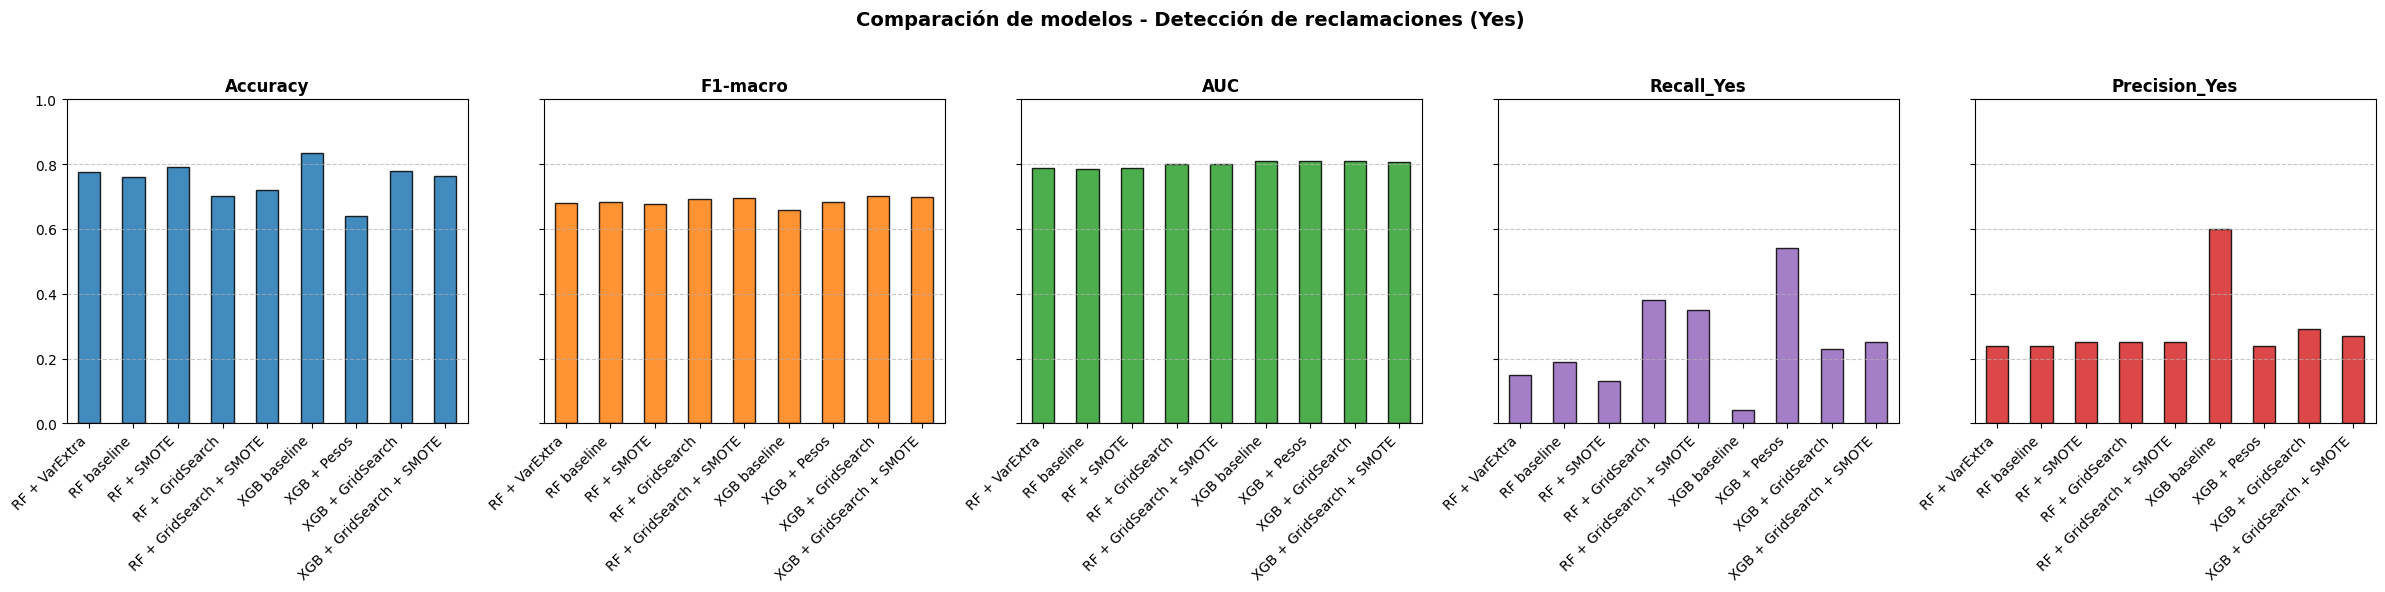

In [44]:
resultados = {
    "RF + VarExtra": {"Accuracy": 0.777, "F1-macro": 0.680, "AUC": 0.788, "Recall_Yes": 0.15, "Precision_Yes": 0.24},
    "RF baseline": {"Accuracy": 0.761, "F1-macro": 0.684, "AUC": 0.785, "Recall_Yes": 0.19, "Precision_Yes": 0.24},
    "RF + SMOTE": {"Accuracy": 0.791, "F1-macro": 0.678, "AUC": 0.789, "Recall_Yes": 0.13, "Precision_Yes": 0.25},
    "RF + GridSearch": {"Accuracy": 0.703, "F1-macro": 0.694, "AUC": 0.801, "Recall_Yes": 0.38, "Precision_Yes": 0.25},
    "RF + GridSearch + SMOTE": {"Accuracy": 0.719, "F1-macro": 0.696, "AUC": 0.799, "Recall_Yes": 0.35, "Precision_Yes": 0.25},
    "XGB baseline": {"Accuracy": 0.835, "F1-macro": 0.658, "AUC": 0.810, "Recall_Yes": 0.04, "Precision_Yes": 0.60},
    "XGB + Pesos": {"Accuracy": 0.640, "F1-macro": 0.682, "AUC": 0.810, "Recall_Yes": 0.54, "Precision_Yes": 0.24},
    "XGB + GridSearch": {"Accuracy": 0.778, "F1-macro": 0.703, "AUC": 0.809, "Recall_Yes": 0.23, "Precision_Yes": 0.29},
    "XGB + GridSearch + SMOTE": {"Accuracy": 0.764, "F1-macro": 0.700, "AUC": 0.808, "Recall_Yes": 0.25, "Precision_Yes": 0.27}
}

df_resultados = pd.DataFrame(resultados).T
fig, axes = plt.subplots(1, 5, figsize=(24, 6), sharey=True)

metricas = ["Accuracy", "F1-macro", "AUC", "Recall_Yes", "Precision_Yes"]
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"]

for i, metrica in enumerate(metricas):
    df_resultados[metrica].plot(
        kind="bar",
        ax=axes[i],
        color=colores[i],
        alpha=0.85,
        edgecolor="black"
    )
    axes[i].set_title(metrica, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
    axes[i].set_xticklabels(df_resultados.index, rotation=45, ha="right")

plt.suptitle("Comparación de modelos - Detección de reclamaciones (Yes)", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

De todos los modelos probados, el que obtiene la mayor accuracy global es XGBoost baseline (0.84). Sin embargo, este modelo prácticamente no identifica los casos de reclamación (clase “Yes”), ya que solo alcanza un recall del 0.04. Esto lo convierte en un modelo muy preciso para las clases mayoritarias (“No” y “Pending”), pero poco útil para el objetivo principal: detectar clientes que reclaman.

El modelo que mejor consigue detectar reclamaciones es XGBoost ajustando pesos, que eleva el recall en la clase “Yes” hasta 0.54 y un f1-score de 0.34, muy por encima del resto. La contrapartida es que su accuracy baja al 0.64, ya que comete más falsos positivos en la clase “No”. Este enfoque es adecuado si la prioridad es no dejar escapar reclamaciones, incluso a costa de una mayor tasa de error en otros casos.

En conclusión, si el objetivo prioritario es maximizar la detección de reclamaciones, el más adecuado es XGBoost con pesos, ya que es el más sensible a la clase “Yes”. En cambio, si se busca un modelo más equilibrado y confiable en términos globales, la mejor opción es XGBoost con Grid Search, que sacrifica algo de recall en “Yes” pero mantiene un desempeño sólido y estable en todas las clases.